In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Подгрузим данные

In [ ]:
diagnosis_data = pd.read_csv(
    filepath_or_buffer="/content/drive/MyDrive/Colab Notebooks/Hackathon/mock-med-data/diagnosis_data.csv"
)
diagnosis_data.head(4)

,код_мкб,название_диагноза,класс_заболевания
0,A00,Холера,НЕКОТОРЫЕ ИНФЕКЦИОННЫЕ И ПАРАЗИТАРНЫЕ БОЛЕЗНИ
1,A00.0,"Холера, вызванная холерным вибрионом 01, биова...",НЕКОТОРЫЕ ИНФЕКЦИОННЫЕ И ПАРАЗИТАРНЫЕ БОЛЕЗНИ
2,A00.1,"Холера, вызванная холерным вибрионом 01, биова...",НЕКОТОРЫЕ ИНФЕКЦИОННЫЕ И ПАРАЗИТАРНЫЕ БОЛЕЗНИ
3,A00.9,Холера неуточненная,НЕКОТОРЫЕ ИНФЕКЦИОННЫЕ И ПАРАЗИТАРНЫЕ БОЛЕЗНИ


## Наличие Nan

In [ ]:
diagnosis_data.isna().sum()

,0
код_мкб,0
название_диагноза,0
класс_заболевания,0


### Информация по типам

In [ ]:
diagnosis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14801 entries, 0 to 14800
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   код_мкб            14801 non-null  object
 1   название_диагноза  14801 non-null  object
 2   класс_заболевания  14801 non-null  object
dtypes: object(3)
memory usage: 347.0+ KB


## Форма датасета

In [ ]:
diagnosis_data.shape

(14801, 3)

## Количество уникальных лэйблов

In [33]:
for col in diagnosis_data.columns:
    print(f"{col} : ", {len(pd.unique(diagnosis_data[col])): pd.unique(diagnosis_data[col])[:10]}, "\n")

код_мкб :  {14801: array(['A00', 'A00.0', 'A00.1', 'A00.9', 'A01', 'A01.0', 'A01.1', 'A01.2',
       'A01.3', 'A01.4'], dtype=object)} 

название_диагноза :  {14678: array(['Холера',
       'Холера, вызванная холерным вибрионом 01, биовар cholerae',
       'Холера, вызванная холерным вибрионом 01, биовар eltor',
       'Холера неуточненная', 'Тиф и паратиф', 'Брюшной тиф', 'Паратиф A',
       'Паратиф B', 'Паратиф C', 'Паратиф неуточненный'], dtype=object)} 

класс_заболевания :  {20: array(['некоторые инфекционные и паразитарные болезни', 'новообразования',
       'не определен', 'болезни нервной системы',
       'болезни мочеполовой системы',
       'болезни крови, кроветворных органов и отдельные нарушения с вовлечением иммунного механизма',
       'болезни эндокринной системы, расстройства питания и нарушения обмена веществ',
       'психические расстройства и расстройства поведения',
       'болезни глаза и придаточного аппарата',
       'болезни уха и сосцевидного отростка'], dty

## Заметим, что данные в классе заболевание записано через боььшие буквы, можно понизить регистр

In [ ]:
diagnosis_data["класс_заболевания"] = diagnosis_data["класс_заболевания"].str.lower()

### Рассмотрим распределение классов заболевания


Text(0.5, 1.0, 'Распредление классов заболеваний')

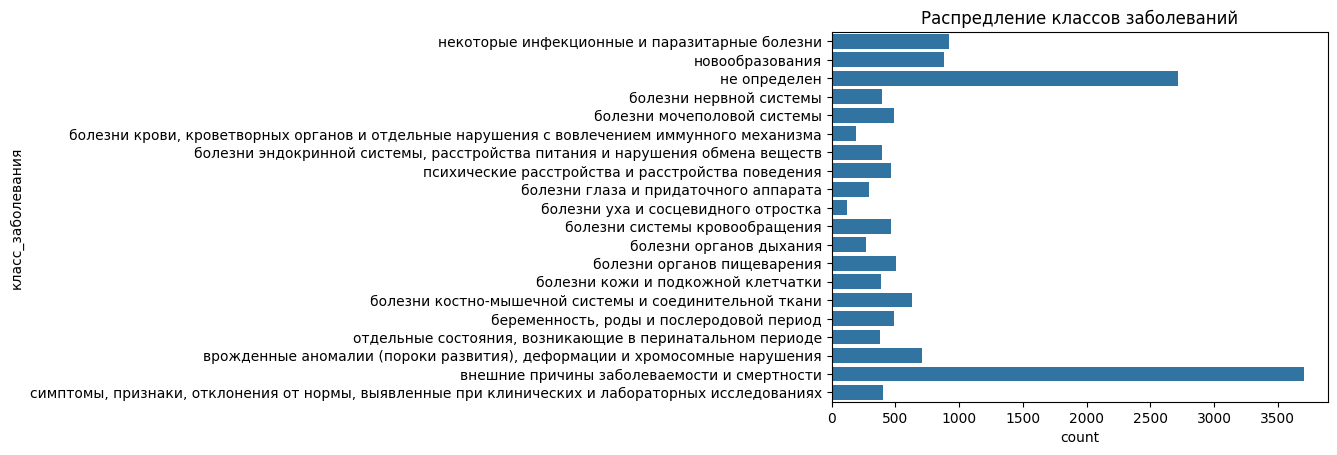

In [ ]:
sns.countplot(y=diagnosis_data["класс_заболевания"])
plt.title("Распредление классов заболеваний")

### Вывод:
  * Чаще всего какое-либо заболевание классифицируют, как `внешние причины заболеваемости и смертности`, `не определен`(что означает, что нельзя никак отнести к каому-либо классу)

### Рассотрим часто встречающиеся название диагнозов

In [ ]:
diagnosis_data.iloc[:, 1].value_counts(ascending=False)[:28]

,count
название_диагноза,
"Различное медицинское оборудование, не классифицированное в других рубриках",13
"Протезы и другие имплантаты, материалы и соответствующие устройства",13
Терапевтические (нехирургические) и реабилитационные приборы и устройства,13
Оборудование для диагностики и мониторинга,13
"Хирургические инструменты, материалы и оборудование (включая шовный материал)",13
"Лицо, пострадавшее при посадке или высадке без столкновения",7
"Пассажир, пострадавший при столкновении с другими и неуточненными мототранспортными средствами в результате дорожного несчастного случая",7
"Водитель, пострадавший при столкновении с другими и неуточненными мототранспортными средствами в результате дорожного несчастного случая",6
"Водитель, пострадавший при столкновении с другими и неуточненными мототранспортными средствами в результате недорожного несчастного случая",5


Проверим один из часто встречающихся названий заболевания через выбор подмножества строк

In [ ]:
diagnosis_data[
    diagnosis_data["название_диагноза"] == "Различное медицинское оборудование, не классифицированное в других рубриках"
]

,код_мкб,название_диагноза,класс_заболевания
13918,Y70.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13924,Y71.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13930,Y72.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13936,Y73.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13942,Y74.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13948,Y75.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13954,Y76.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13960,Y77.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13966,Y78.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности
13972,Y79.8,"Различное медицинское оборудование, не классиф...",внешние причины заболеваемости и смертности


No charts were generated by quickchart


In [ ]:
diagnosis_data[
    diagnosis_data["название_диагноза"] == "Терапевтические (нехирургические) и реабилитационные приборы и устройства"
]

,код_мкб,название_диагноза,класс_заболевания
13915,Y70.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13921,Y71.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13927,Y72.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13933,Y73.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13939,Y74.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13945,Y75.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13951,Y76.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13957,Y77.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13963,Y78.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности
13969,Y79.1,Терапевтические (нехирургические) и реабилитац...,внешние причины заболеваемости и смертности


In [ ]:
diagnosis_data[diagnosis_data["название_диагноза"] == "Оборудование для диагностики и мониторинга"]

,код_мкб,название_диагноза,класс_заболевания
13914,Y70.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13920,Y71.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13926,Y72.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13932,Y73.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13938,Y74.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13944,Y75.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13950,Y76.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13956,Y77.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13962,Y78.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности
13968,Y79.0,Оборудование для диагностики и мониторинга,внешние причины заболеваемости и смертности


### Выводы:
  * Чаще всего к разным кодам МКБ  в названии заболевания ставят
    - `Различное медицинское оборудование, не классифицированное в других рубриках`
    - `Терапевтические (нехирургические) и реабилитационные приборы и устройства`
    - `Оборудование для диагностики и мониторинга`
    - `Хирургические инструменты, материалы и оборудование (включая шовный материал)`
  * При этом часто встречаемые диагнозы имеют зачастую только другой код по мкб, что говорит нам о том, что некоторая дополнительная информация, позволяющая сдлеать отличия очевидными отсутсвует.

# Итоговый вывод:

  - Датасет чист и не имеет проблем с пропущенными значениями
  - `код-мкб` - уникален и может быть использован, как ключ
  - Размер 14801 строка, 3 столбца(Код мкб, Название диагноза, Класс заболевания)
  -  Пригоден к использованию или обогащению
  